In [1]:
import requests
import pandas as pd

LAT, LON = 56.1629, 10.2039  # Aarhus
START, END = "2022-01-01", "2026-04-18"

# ── 1. Historical air quality (NO2, O3) ──────────────────────────────────────
print("Fetching air quality...")
aq = requests.get(
    "https://air-quality-api.open-meteo.com/v1/air-quality",
    params={
        "latitude": LAT,
        "longitude": LON,
        "hourly": "nitrogen_dioxide,ozone,pm10,pm2_5",
        "start_date": START,
        "end_date": END,
        "timezone": "Europe/Copenhagen"
    }
).json()

aq_df = pd.DataFrame({
    "Recorded": pd.to_datetime(aq["hourly"]["time"]),
    "NO2":      aq["hourly"]["nitrogen_dioxide"],
    "O3":       aq["hourly"]["ozone"],
    "PM10":     aq["hourly"]["pm10"],
    "PM2.5":    aq["hourly"]["pm2_5"],
})

# ── 2. Historical weather (wind, rain, temp, radiation) ──────────────────────
print("Fetching weather...")
wx = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude": LAT,
        "longitude": LON,
        "hourly": "wind_speed_10m,wind_direction_10m,temperature_2m,shortwave_radiation,precipitation,relative_humidity_2m",
        "wind_speed_unit": "ms",
        "start_date": START,
        "end_date": END,
        "timezone": "Europe/Copenhagen"
    }
).json()

wx_df = pd.DataFrame({
    "Recorded":           pd.to_datetime(wx["hourly"]["time"]),
    "wind_speed":         wx["hourly"]["wind_speed_10m"],
    "wind_direction":     wx["hourly"]["wind_direction_10m"],
    "temperature":        wx["hourly"]["temperature_2m"],
    "solar_radiation":    wx["hourly"]["shortwave_radiation"],
    "precipitation":      wx["hourly"]["precipitation"],
    "humidity":           wx["hourly"]["relative_humidity_2m"],

})

# ── 3. Merge and save ─────────────────────────────────────────────────────────
print("Merging...")
df = aq_df.merge(wx_df, on="Recorded", how="inner")
df = df.sort_values("Recorded").reset_index(drop=True)

print(f"\nFinal shape: {df.shape}")
print(df.head())
print(f"\nDate range: {df.Recorded.min()} → {df.Recorded.max()}")
print(f"Missing values:\n{df.isnull().sum()}")

df.to_csv("aarhus_air_quality.csv", index=False)
print("\nSaved to aarhus_air_quality.csv")

Fetching air quality...
Fetching weather...
Merging...

Final shape: (37656, 11)
             Recorded  NO2    O3  PM10  PM2.5  wind_speed  wind_direction  \
0 2022-01-01 00:00:00  6.2  53.0   6.2    5.0        5.00             269   
1 2022-01-01 01:00:00  4.6  53.0   6.4    4.7        5.00             272   
2 2022-01-01 02:00:00  5.0  57.0   6.0    4.5        4.90             269   
3 2022-01-01 03:00:00  5.0  54.0   5.4    4.6        4.72             265   
4 2022-01-01 04:00:00  5.7  52.0   5.3    4.9        4.53             264   

   temperature  solar_radiation  precipitation  humidity  
0          6.7              0.0            0.0        98  
1          7.2              0.0            0.0        98  
2          7.1              0.0            0.0        97  
3          7.1              0.0            0.0        97  
4          7.1              0.0            0.0        96  

Date range: 2022-01-01 00:00:00 → 2026-04-18 23:00:00
Missing values:
Recorded           0
NO2       

In [2]:
df.head()

,Recorded,NO2,O3,PM10,PM2.5,wind_speed,wind_direction,temperature,solar_radiation,precipitation,humidity
0,2022-01-01 00:00:00,6.2,53.0,6.2,5.0,5.00,269,6.7,0.0,0.0,98
1,2022-01-01 01:00:00,4.6,53.0,6.4,4.7,5.00,272,7.2,0.0,0.0,98
2,2022-01-01 02:00:00,5.0,57.0,6.0,4.5,4.90,269,7.1,0.0,0.0,97
3,2022-01-01 03:00:00,5.0,54.0,5.4,4.6,4.72,265,7.1,0.0,0.0,97
4,2022-01-01 04:00:00,5.7,52.0,5.3,4.9,4.53,264,7.1,0.0,0.0,96


In [3]:
df.describe()

,Recorded,NO2,O3,PM10,PM2.5,wind_speed,wind_direction,temperature,solar_radiation,precipitation,humidity
count,37656,37656.000000,37656.000000,37656.000000,37656.000000,37656.000000,37656.000000,37656.000000,37656.000000,37656.000000,37656.000000
mean,2024-02-24 11:30:00,6.091096,62.086908,10.321943,6.716380,4.660753,203.508631,9.057226,123.618733,0.093233,81.081820
min,2022-01-01 00:00:00,0.600000,4.000000,1.300000,0.900000,0.050000,1.000000,-12.600000,0.000000,0.000000,22.000000
25%,2023-01-28 05:45:00,3.200000,51.000000,6.800000,3.700000,3.020000,138.000000,4.200000,0.000000,0.000000,73.000000
50%,2024-02-24 11:30:00,5.000000,63.000000,9.200000,5.400000,4.430000,219.000000,8.800000,4.000000,0.000000,84.000000
75%,2025-03-22 17:15:00,7.800000,74.000000,12.500000,8.300000,6.040000,272.000000,14.100000,180.000000,0.000000,92.000000
max,2026-04-18 23:00:00,38.000000,159.000000,59.100000,46.700000,15.370000,360.000000,27.700000,864.000000,11.200000,100.000000
std,NaN,4.093075,17.348296,5.206703,4.470867,2.184536,85.405097,6.468670,196.063059,0.386187,13.083754


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

In [10]:
df_filtered = df[
    (df["Recorded"] >= "2024-01-01 00:00:00") &
    (df["Recorded"] <= "2025-01-01 00:00:00")
]

def plot_time_series(df, column):
    plt.figure()
    plt.plot(df["Recorded"], df[column])
    plt.title(f"{column} over time")
    plt.xlabel("Time")
    plt.ylabel(column)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot entire time range:

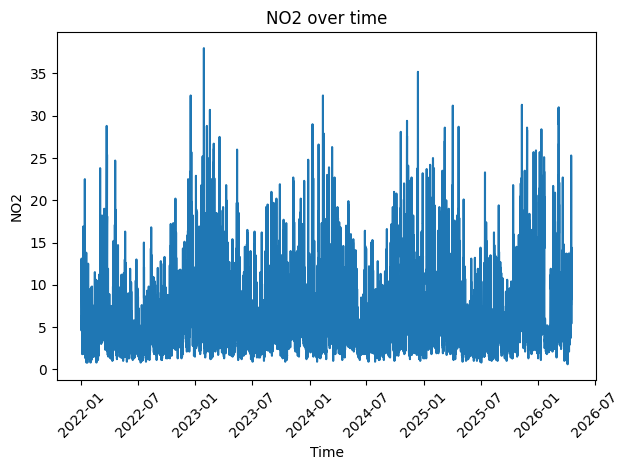

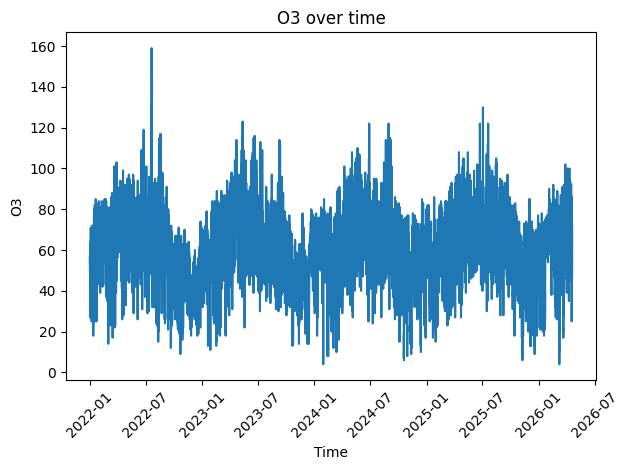

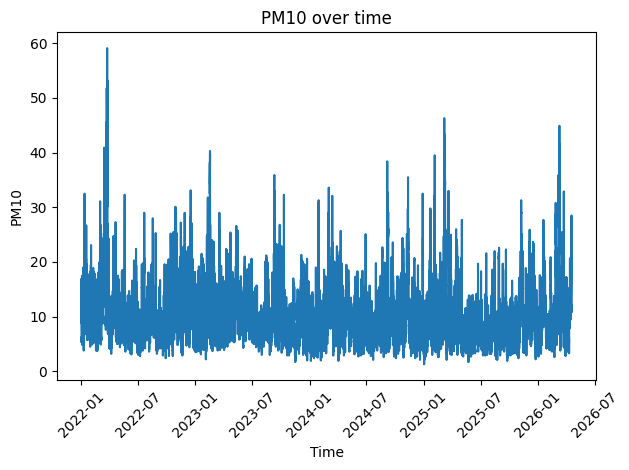

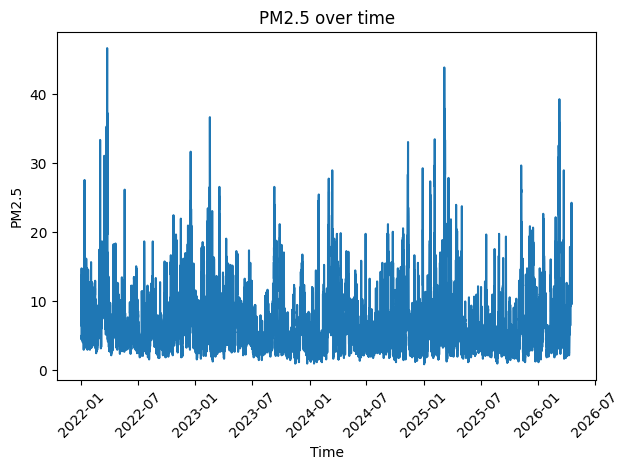

In [ ]:
for col in ["NO2", "O3", "PM10", "PM2.5"]:
    plot_time_series(df, col)

# Plot a year:

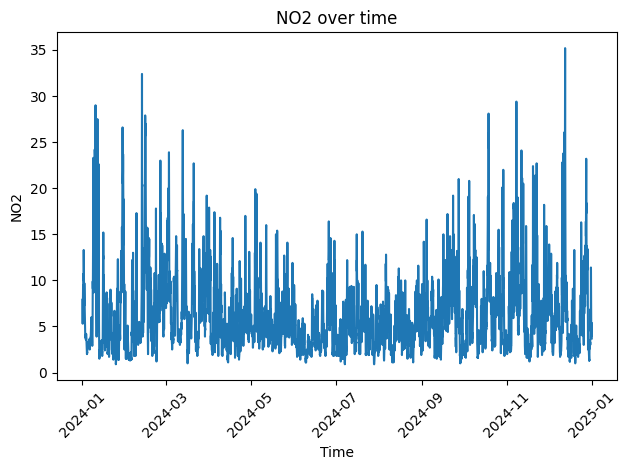

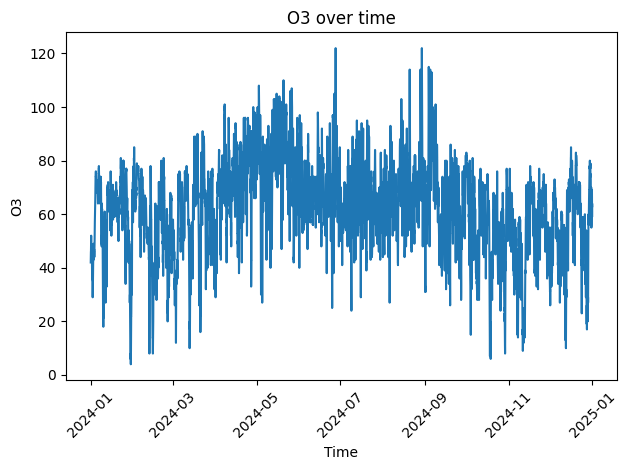

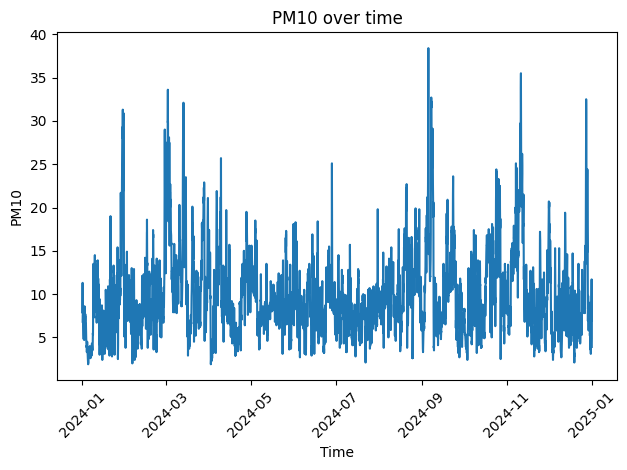

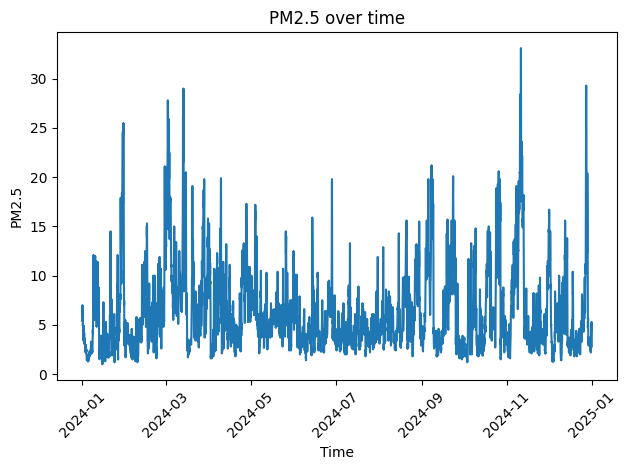

In [11]:
for col in ["NO2", "O3", "PM10", "PM2.5"]:
    plot_time_series(df_filtered, col)

# Seasonal Plots

In [12]:
df["Recorded"] = pd.to_datetime(df["Recorded"])

df_o3 = df[
    (df["Recorded"] >= "2022-01-01") &
    (df["Recorded"] <= "2026-04-18")
].copy()

# Extract time components
df_o3["year"] = df_o3["Recorded"].dt.year
df_o3["month"] = df_o3["Recorded"].dt.month
df_o3["dayofyear"] = df_o3["Recorded"].dt.dayofyear
df_o3["hour"] = df_o3["Recorded"].dt.hour
df_o3["week"] = df_o3["Recorded"].dt.isocalendar().week

In [23]:
df["Recorded"] = pd.to_datetime(df["Recorded"])

df = df[
    (df["Recorded"] >= "2022-01-01") &
    (df["Recorded"] <= "2026-04-18")
].copy()

# Extract time components
df["year"] = df["Recorded"].dt.year
df["month"] = df["Recorded"].dt.month
df["dayofyear"] = df["Recorded"].dt.dayofyear
df["hour"] = df["Recorded"].dt.hour
df["week"] = df["Recorded"].dt.isocalendar().week

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def seasonal_plot_yearly(df, value_col):
    years = sorted(df["year"].unique())
    colors = plt.cm.rainbow(np.linspace(0, 1, len(years)))

    plt.figure()

    for y, c in zip(years, colors):
        subset = df[df["year"] == y]
        monthly = subset.groupby("month")[value_col].mean()
        plt.plot(monthly.index, monthly.values, label=str(y), color=c)

    plt.title(f"Seasonal plot (yearly overlay) - {value_col}")
    plt.xlabel("Month")
    plt.ylabel(value_col)
    plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

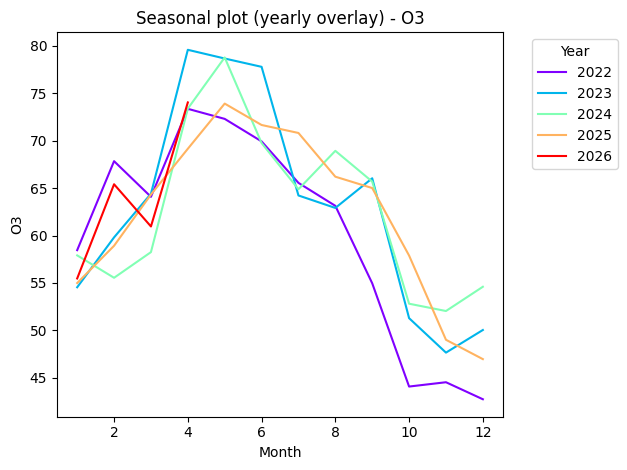

In [14]:
seasonal_plot_yearly(df_o3, "O3")


In [15]:
def seasonal_plot_dayofyear(df, value_col):
    years = sorted(df["year"].unique())
    colors = plt.cm.rainbow(np.linspace(0, 1, len(years)))

    plt.figure()

    for y, c in zip(years, colors):
        subset = df[df["year"] == y]
        daily = subset.groupby("dayofyear")[value_col].mean()
        plt.plot(daily.index, daily.values, color=c, alpha=0.8)

    plt.title(f"Seasonal plot (day-of-year) - {value_col}")
    plt.xlabel("Day of Year")
    plt.ylabel(value_col)
    plt.tight_layout()
    plt.show()

In [19]:

def seasonal_plot_weekday_all(df, value_col):
    df = df.copy()
    
    # Extract components
    df["year"] = df["Recorded"].dt.isocalendar().year
    df["week"] = df["Recorded"].dt.isocalendar().week
    df["weekday"] = df["Recorded"].dt.weekday  # Monday=0
    
    # Create unique week ID (year-week)
    df["year_week"] = df["year"].astype(str) + "-" + df["week"].astype(str)
    
    weeks = df["year_week"].unique()
    colors = plt.cm.rainbow(np.linspace(0, 1, len(weeks)))
    
    plt.figure()

    for w, c in zip(weeks, colors):
        subset = df[df["year_week"] == w]
        
        # average within each weekday (in case multiple obs per day)
        weekday_avg = subset.groupby("weekday")[value_col].mean()
        
        # Only plot full weeks (optional but cleaner)
        if len(weekday_avg) == 7:
            plt.plot(
                weekday_avg.index,
                weekday_avg.values,
                color=c,
                alpha=0.4
            )

    plt.xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    plt.title(f"Weekly seasonal plot (all weeks) - {value_col}")
    plt.xlabel("Day of week")
    plt.ylabel(value_col)
    plt.tight_layout()
    plt.show()

In [17]:
def seasonal_plot_hourly(df, value_col):
    years = sorted(df["year"].unique())
    colors = plt.cm.rainbow(np.linspace(0, 1, len(years)))

    plt.figure()

    for y, c in zip(years, colors):
        subset = df[df["year"] == y]
        hourly = subset.groupby("hour")[value_col].mean()
        plt.plot(hourly.index, hourly.values, color=c, alpha=0.8)

    plt.title(f"Seasonal plot (hour of day) - {value_col}")
    plt.xlabel("Hour")
    plt.ylabel(value_col)
    plt.tight_layout()
    plt.show()

In [21]:


def seasonal_plot_daily_all(df, value_col):
    df = df.copy()

    # Extract date + hour
    df["date"] = df["Recorded"].dt.date
    df["hour"] = df["Recorded"].dt.hour

    days = df["date"].unique()
    colors = plt.cm.rainbow(np.linspace(0, 1, len(days)))

    plt.figure()

    for d, c in zip(days, colors):
        subset = df[df["date"] == d]

        # average per hour (in case multiple rows per hour)
        hourly = subset.groupby("hour")[value_col].mean()

        # only plot full days (optional but cleaner)
        if len(hourly) == 24:
            plt.plot(hourly.index, hourly.values, color=c, alpha=0.3)

    plt.title(f"Daily seasonal plot (all days) - {value_col}")
    plt.xlabel("Hour of day")
    plt.ylabel(value_col)
    plt.xticks(range(0, 24, 2))
    plt.tight_layout()
    plt.show()

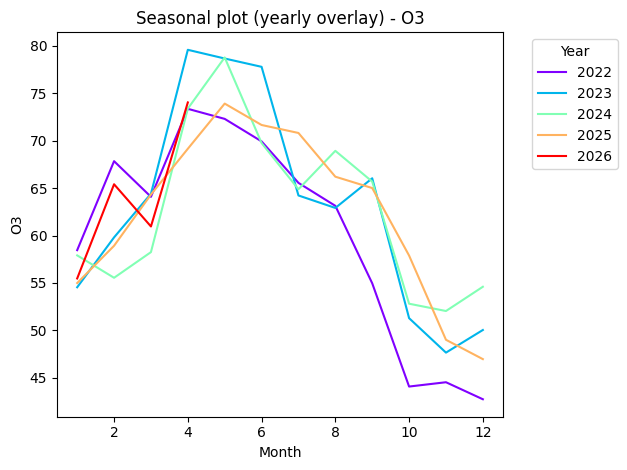

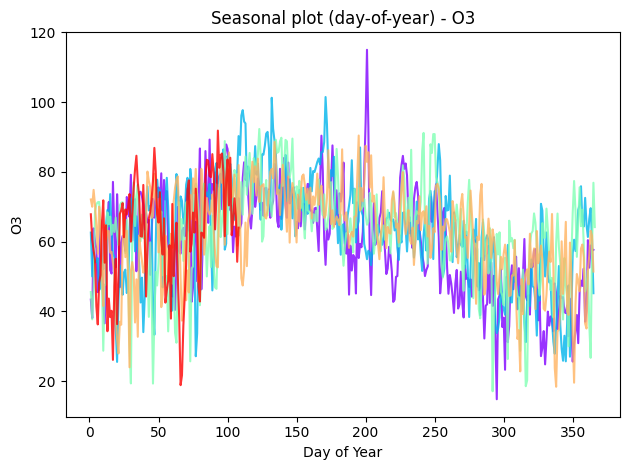

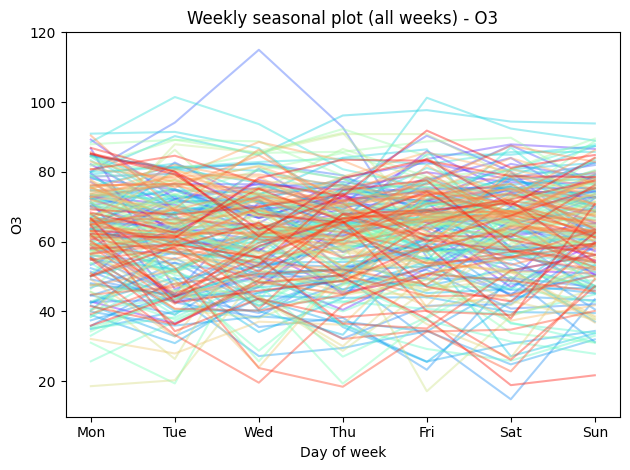

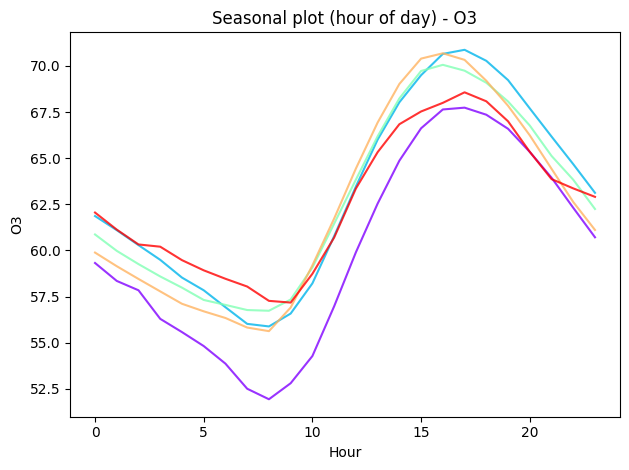

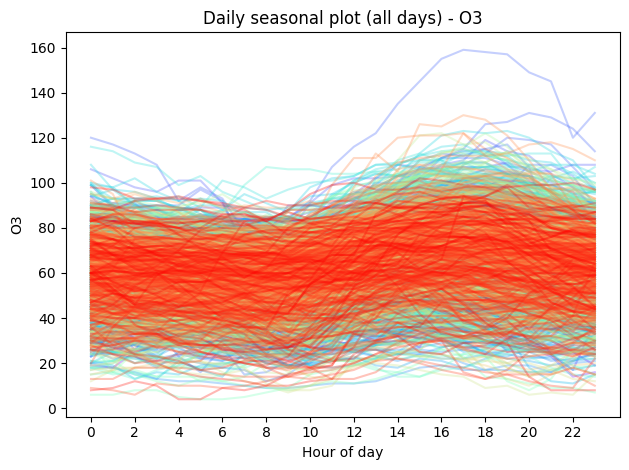

In [24]:
seasonal_plot_yearly(df, "O3")
seasonal_plot_dayofyear(df, "O3")
seasonal_plot_weekday_all(df, "O3")
seasonal_plot_hourly(df, "O3")
seasonal_plot_daily_all(df, "O3")

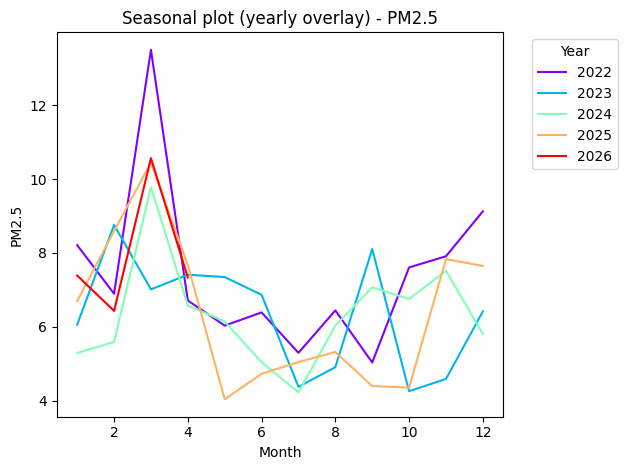

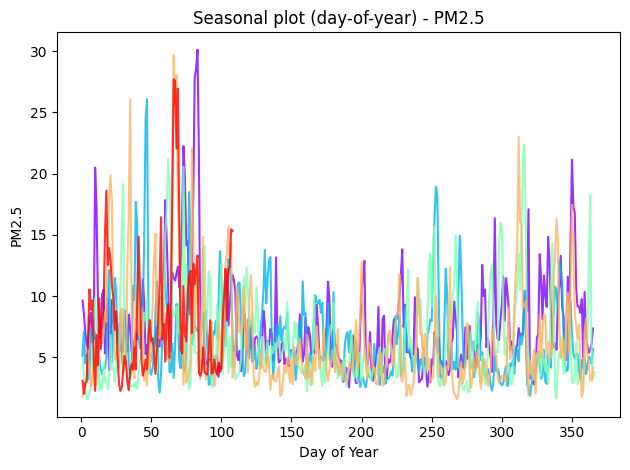

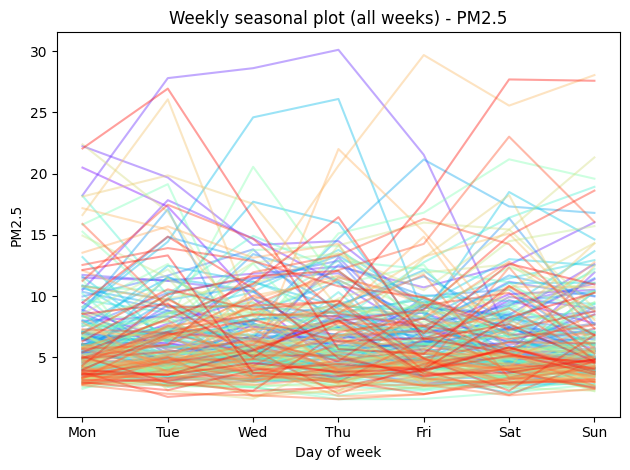

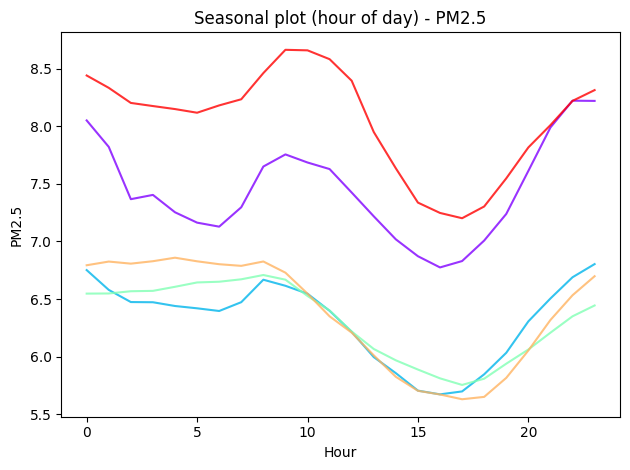

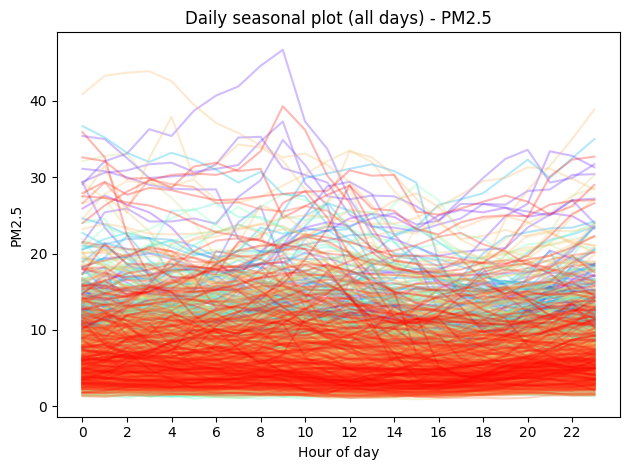

In [25]:
seasonal_plot_yearly(df, "PM2.5")
seasonal_plot_dayofyear(df, "PM2.5")
seasonal_plot_weekday_all(df, "PM2.5")
seasonal_plot_hourly(df, "PM2.5")
seasonal_plot_daily_all(df, "PM2.5")

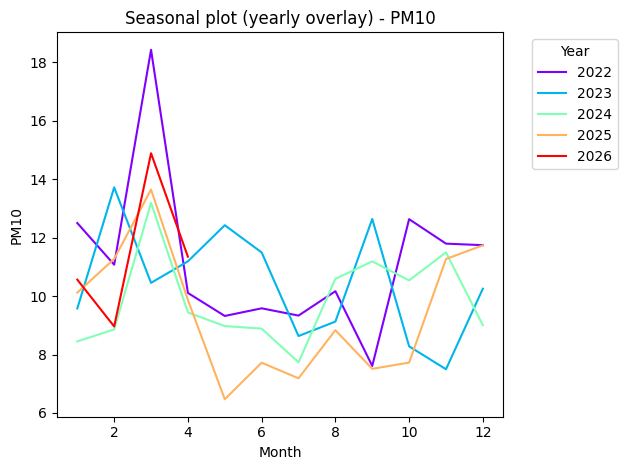

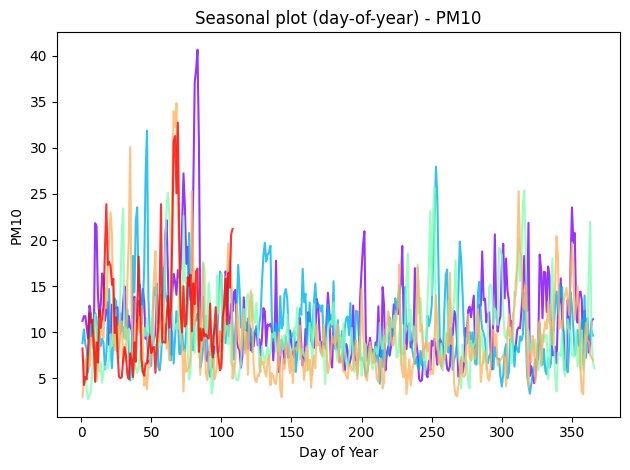

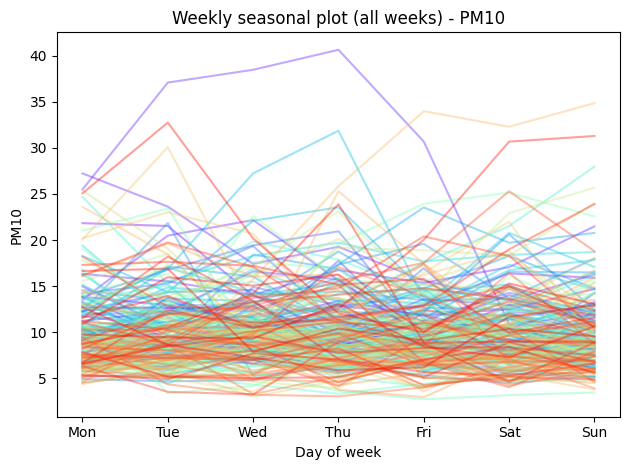

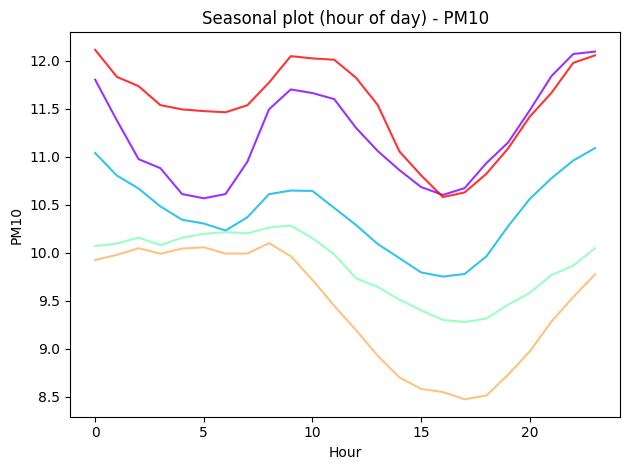

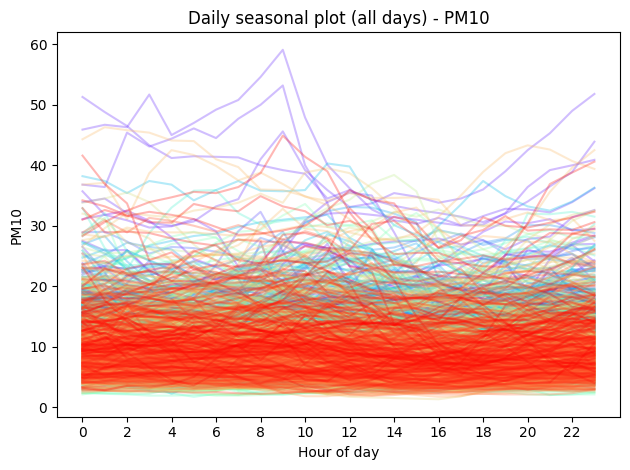

In [26]:
seasonal_plot_yearly(df, "PM10")
seasonal_plot_dayofyear(df, "PM10")
seasonal_plot_weekday_all(df, "PM10")
seasonal_plot_hourly(df, "PM10")
seasonal_plot_daily_all(df, "PM10")

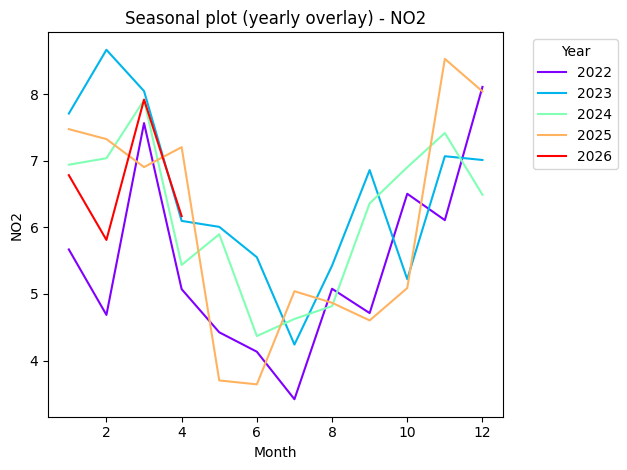

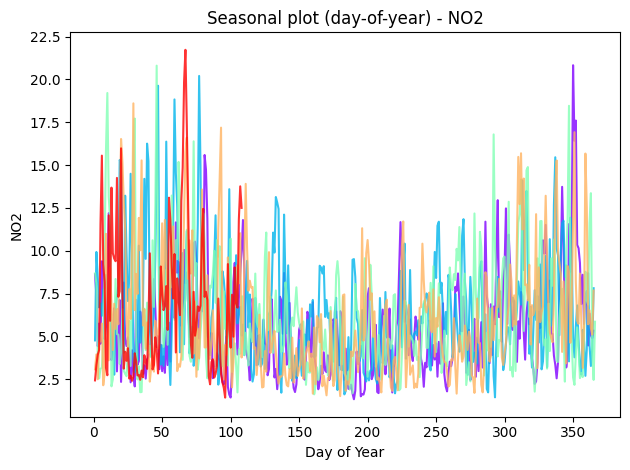

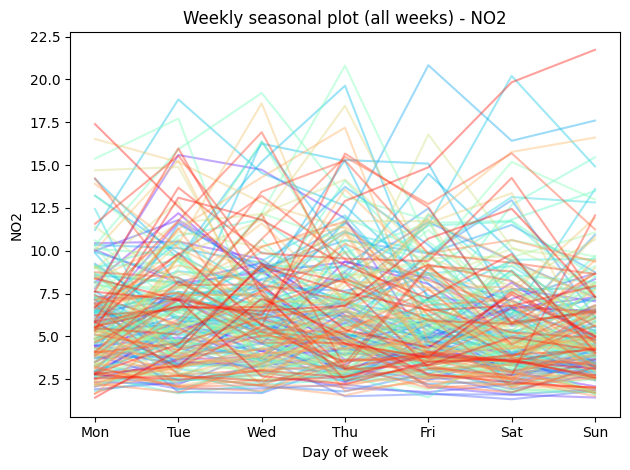

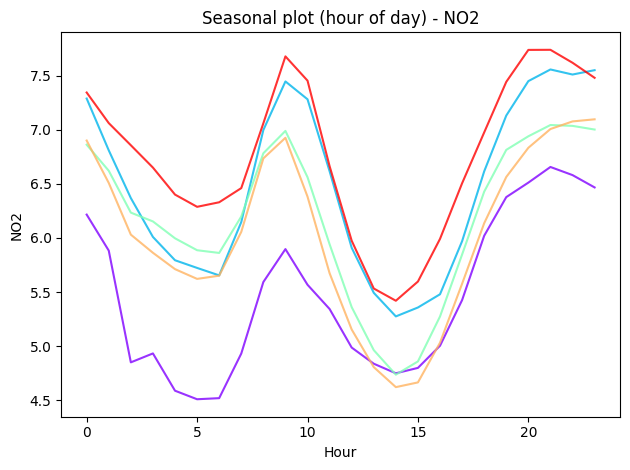

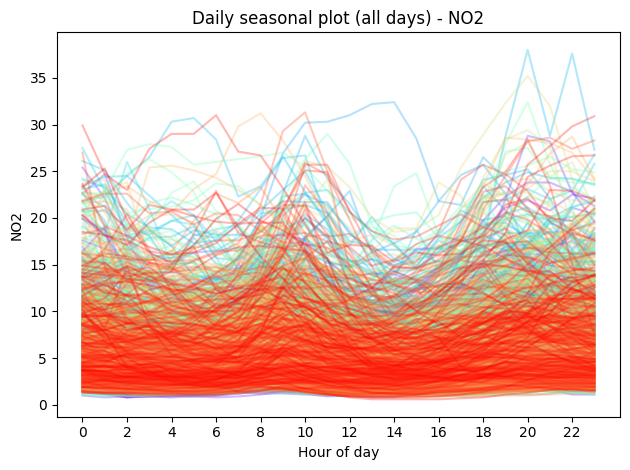

In [27]:
seasonal_plot_yearly(df, "NO2")
seasonal_plot_dayofyear(df, "NO2")
seasonal_plot_weekday_all(df, "NO2")
seasonal_plot_hourly(df, "NO2")
seasonal_plot_daily_all(df, "NO2")

# Autocorrelation plots

In [33]:
def plot_acf_variable(df, col, lags=48):
    plt.figure()
    plot_acf(df[col].dropna(), lags=lags, alpha=.05)
    plt.title(f"ACF - {col}")
    plt.tight_layout()
    plt.show()

<Figure size 640x480 with 0 Axes>

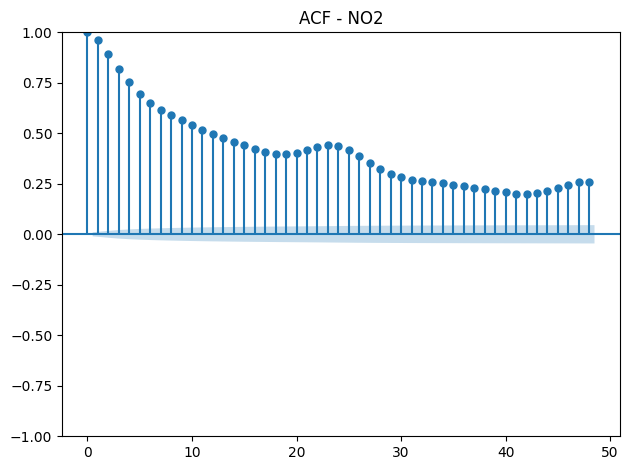

<Figure size 640x480 with 0 Axes>

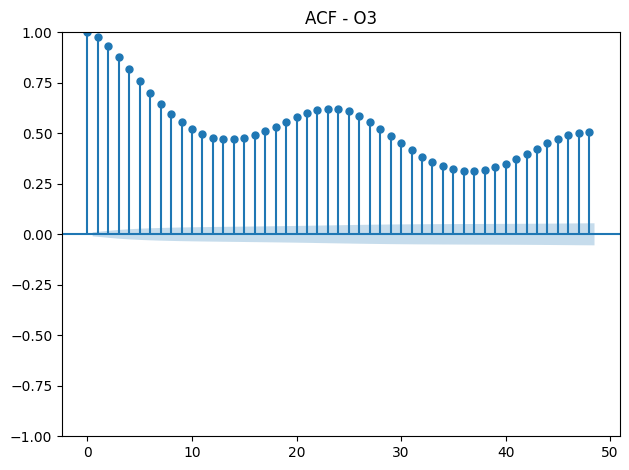

<Figure size 640x480 with 0 Axes>

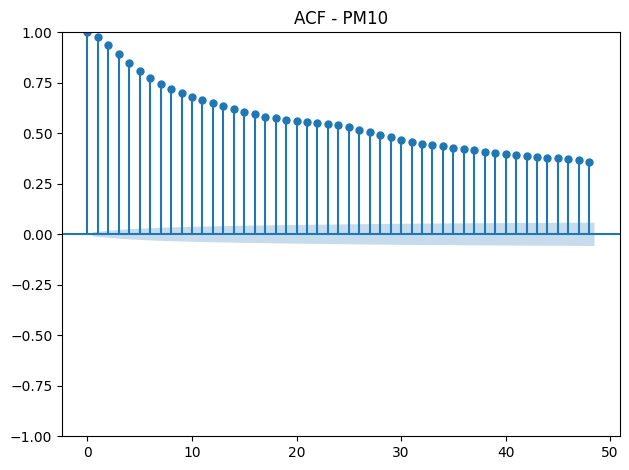

<Figure size 640x480 with 0 Axes>

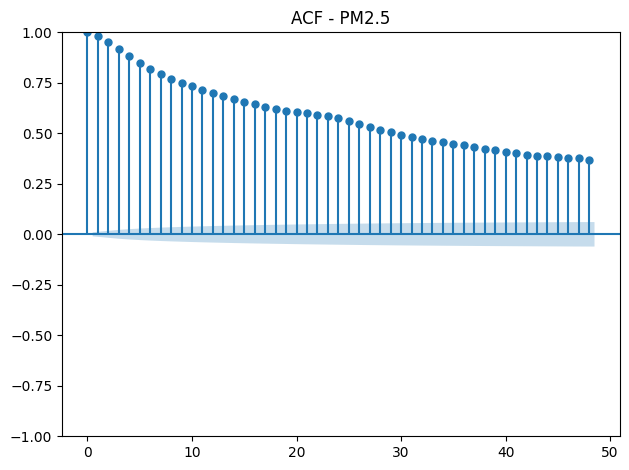

In [34]:

for v in ["NO2", "O3", "PM10", "PM2.5"]:
    plot_acf_variable(df, v)